# 3. Random Forest: feature engineering, partial SMOTENC and tuning
Compare 8 configurations in this order: original features/no oversampling (2 settings); engineered features/no oversampling (2); engineered features with buyer:non-buyer = 1:2 (2); engineered features with 3:4 (2). Select configuration and threshold using 3-fold stratified training out-of-fold (OOF) buyer F1. This small budget is a comparative experiment, not exhaustive tuning.


## Validity
The 20% holdout is reused from earlier experiments. Tuning never uses its labels, but reported before/after test results are exploratory, not independent confirmation. Selection OOF scores are optimistic after searching; they are not unbiased estimates. Previous 5-fold scores are not directly comparable to these 3-fold selection scores. All six models here share the same split and folds.

Preprocessing and SMOTENC fit within training folds only. Validation/test data retain their original class distribution. Category columns are ordinal encoded for SMOTENC then one-hot encoded afterward. Numerical columns are standardized before neighbor-based sampling. The target is never a feature. SMOTENC ratios mean minority/majority counts after resampling, not percentage buyers. Synthetic interpolation may not preserve all relationships among engineered columns, so this is an experiment to validate, not automatically an improvement.

Engineered features: total pages, total duration, total duration / max(total pages,1), product pages / max(total pages,1), and product duration / max(product pages,1). These use each session only. Confirm all source values are available at prediction time, especially PageValues. No IQR capping, PCA or VIF elimination is applied.

For LR/RF/SVM/Decision Tree, no-sampling configurations use balanced class weights; sampled configurations use no extra class weights to avoid compounding corrections. Thus comparisons include that strategy change. KNN and MLP have no class weighting here. MLP early stopping uses internal accuracy and, after sampling, its internal subset can contain synthetic examples related to its internal training rows; the outer CV validation and test remain untouched and determine selection/evaluation.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
 average_precision_score,roc_auc_score,balanced_accuracy_score,classification_report,
 ConfusionMatrixDisplay,PrecisionRecallDisplay,RocCurveDisplay)
from model_helpers import build_pipeline,configurations,scores,variants
NAME='Random Forest'
OUT=Path('outputs')/NAME.replace(' ','_');OUT.mkdir(parents=True,exist_ok=True)
df=pd.read_csv('online_shoppers_intention.csv')
X=df.drop(columns='Revenue');y=df['Revenue'].astype(int)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
configs=configurations(NAME)
thresholds=np.linspace(-1,1,41) if NAME=='SVM' else np.round(np.linspace(.2,.7,51),2)
default_threshold=0.0 if NAME=='SVM' else .5
records=[];oof_scores={}
print('Training:',len(y_train),'Testing:',len(y_test),'Buyer fraction:',y.mean())
for idx,cfg in enumerate(configs):
 print(idx,cfg,variants(NAME,cfg['ratio'] is not None)[cfg['variant']])


Training: 9864 Testing: 2466 Buyer fraction: 0.15474452554744525
0 {'engineered': False, 'ratio': None, 'variant': 0} RandomForestClassifier(class_weight='balanced', min_samples_leaf=4,
                       n_estimators=200, n_jobs=-1, random_state=42)
1 {'engineered': False, 'ratio': None, 'variant': 1} RandomForestClassifier(class_weight='balanced', min_samples_leaf=10,
                       n_estimators=200, n_jobs=-1, random_state=42)
2 {'engineered': True, 'ratio': None, 'variant': 0} RandomForestClassifier(class_weight='balanced', min_samples_leaf=4,
                       n_estimators=200, n_jobs=-1, random_state=42)
3 {'engineered': True, 'ratio': None, 'variant': 1} RandomForestClassifier(class_weight='balanced', min_samples_leaf=10,
                       n_estimators=200, n_jobs=-1, random_state=42)
4 {'engineered': True, 'ratio': 0.5, 'variant': 0} RandomForestClassifier(min_samples_leaf=4, n_estimators=200, n_jobs=-1,
                       random_state=42)
5 {'engineer

## Fit each experiment using training folds only
Each model is trained 24 times (8 configurations × 3 folds). Every OOF score comes from a model that did not train on that validation row. Thresholds are searched on these OOF scores; SVM uses decision scores (not probabilities), with default threshold zero. Other models use purchase probabilities. A stable first-occurrence rule breaks F1 ties.


In [2]:
config_id=0
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         0       False  None        0       0.53 0.684766       0.634433    0.743775


In [3]:
config_id=1
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         1       False  None        1        0.6 0.672727       0.625705    0.727392


In [4]:
config_id=2
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         2        True  None        0       0.48 0.684891       0.621002    0.763434


In [5]:
config_id=3
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         3        True  None        1       0.52 0.672819       0.586829    0.788336


In [6]:
config_id=4
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered  ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         4        True    0.5        0       0.43 0.687818       0.633058    0.752949


In [7]:
config_id=5
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered  ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         5        True    0.5        1       0.46 0.677696       0.636364    0.724771


In [8]:
config_id=6
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered  ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         6        True   0.75        0       0.47 0.680965       0.624249    0.749017


In [9]:
config_id=7
cfg=configs[config_id]
method='decision_function' if NAME=='SVM' else 'predict_proba'
oof=cross_val_predict(build_pipeline(NAME,cfg),X_train,y_train,cv=cv,method=method,n_jobs=1)
if NAME!='SVM':oof=oof[:,1]
oof_scores[config_id]=oof
for threshold in thresholds:
 p=(oof>=threshold).astype(int)
 records.append({'config_id':config_id,**cfg,'threshold':float(threshold),
  'OOF F1':f1_score(y_train,p),'OOF precision':precision_score(y_train,p,zero_division=0),
  'OOF recall':recall_score(y_train,p)})
local=pd.DataFrame([r for r in records if r['config_id']==config_id])
print(local.sort_values('OOF F1',ascending=False).head(1).to_string(index=False))


 config_id  engineered  ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         7        True   0.75        1       0.47 0.680197       0.609984    0.768676


Selected training-only configuration: {'engineered': True, 'ratio': 0.5, 'variant': 0} Threshold: 0.43
Selected OOF F1: 0.6878180185573182
 config_id  engineered  ratio  variant  threshold   OOF F1  OOF precision  OOF recall
         0       False    NaN        0       0.53 0.684766       0.634433    0.743775
         1       False    NaN        1       0.60 0.672727       0.625705    0.727392
         2        True    NaN        0       0.48 0.684891       0.621002    0.763434
         3        True    NaN        1       0.52 0.672819       0.586829    0.788336
         4        True   0.50        0       0.43 0.687818       0.633058    0.752949
         5        True   0.50        1       0.46 0.677696       0.636364    0.724771
         6        True   0.75        0       0.47 0.680965       0.624249    0.749017
         7        True   0.75        1       0.47 0.680197       0.609984    0.768676


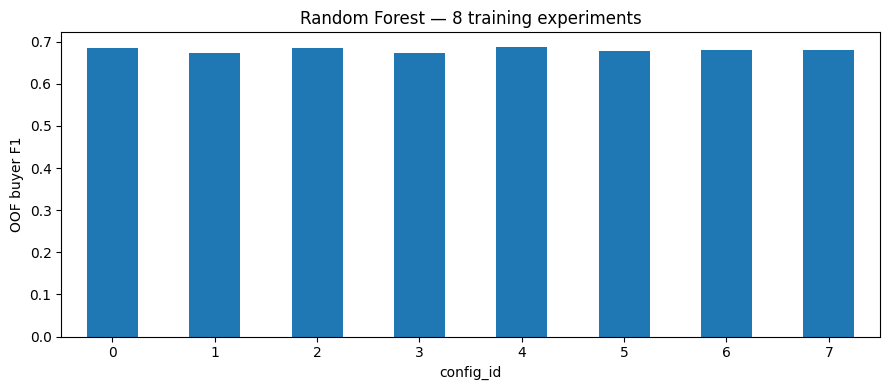

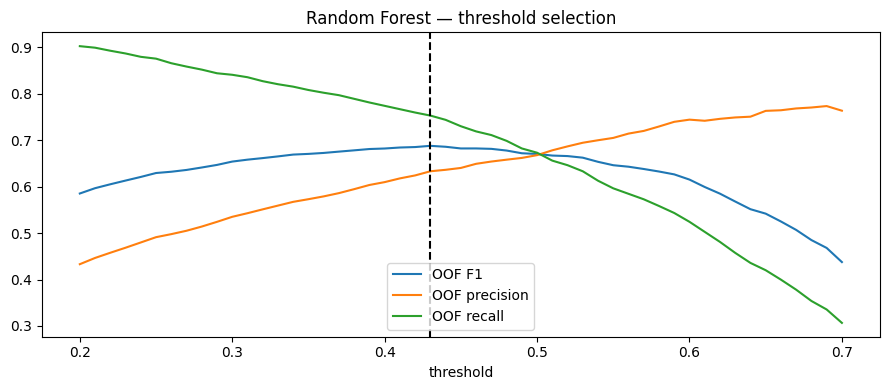

In [10]:
search=pd.DataFrame(records)
best=search.loc[search['OOF F1'].idxmax()]
selected_id=int(best['config_id']);threshold=float(best['threshold'])
config=configs[selected_id]
print('Selected training-only configuration:',config,'Threshold:',threshold)
print('Selected OOF F1:',best['OOF F1'])
search.to_csv(OUT/'search_results.csv',index=False)
ablation=search.loc[search.groupby('config_id')['OOF F1'].idxmax()].sort_values('config_id')
print(ablation.to_string(index=False));ablation.to_csv(OUT/'experiment_comparison.csv',index=False)
ablation.set_index('config_id')['OOF F1'].plot.bar(rot=0,figsize=(9,4))
plt.ylabel('OOF buyer F1');plt.title(NAME+' — 8 training experiments')
plt.tight_layout();plt.savefig(OUT/'experiments.png',dpi=150);plt.show()
search[search.config_id==selected_id].set_index('threshold')[['OOF F1','OOF precision','OOF recall']].plot(figsize=(9,4))
plt.axvline(threshold,ls='--',color='black');plt.title(NAME+' — threshold selection')
plt.tight_layout();plt.savefig(OUT/'threshold.png',dpi=150);plt.show()
model=build_pipeline(NAME,config).fit(X_train,y_train)
score=scores(model,X_test,NAME);pred=(score>=threshold).astype(int)


                                Accuracy  Buyer precision  Buyer recall  Buyer F1  Average precision  ROC-AUC  Balanced accuracy
Previous experiment               0.8816           0.5957         0.733    0.6573             0.7174   0.9216             0.8209
Current CV-selected experiment    0.8893           0.6208         0.733    0.6723             0.6902   0.9171             0.8255
              precision    recall  f1-score   support

           0     0.9494    0.9179    0.9334      2084
           1     0.6208    0.7330    0.6723       382

    accuracy                         0.8893      2466
   macro avg     0.7851    0.8255    0.8028      2466
weighted avg     0.8985    0.8893    0.8929      2466

Saved pipeline, threshold and selected configuration.


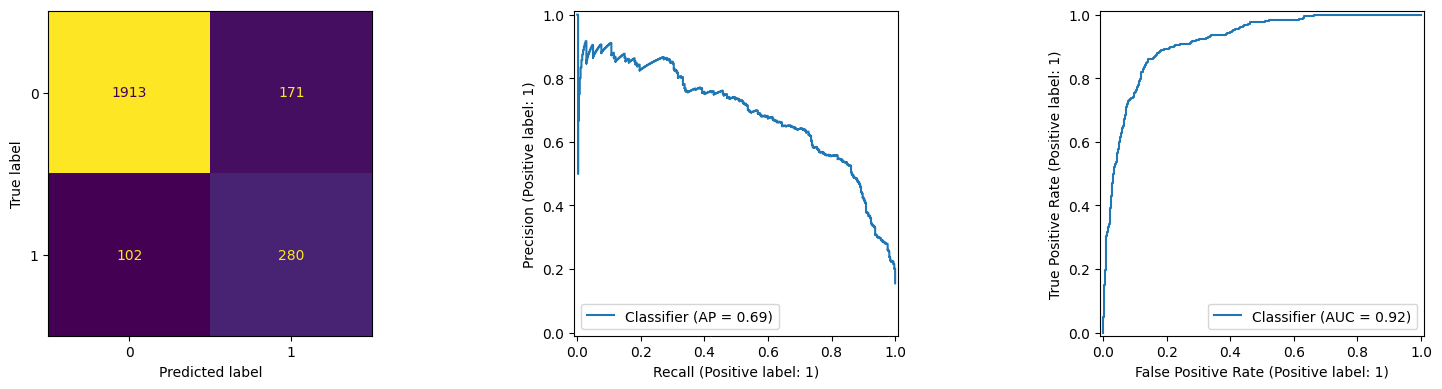

In [11]:
metrics={'Accuracy':accuracy_score(y_test,pred),'Buyer precision':precision_score(y_test,pred,zero_division=0),
 'Buyer recall':recall_score(y_test,pred),'Buyer F1':f1_score(y_test,pred),
 'Average precision':average_precision_score(y_test,score),'ROC-AUC':roc_auc_score(y_test,score),
 'Balanced accuracy':balanced_accuracy_score(y_test,pred)}
previous=pd.read_csv('previous_six_model_results.csv',index_col=0).loc[NAME]
comparison=pd.DataFrame({'Previous experiment':previous,'Current CV-selected experiment':metrics}).T
comparison.to_csv(OUT/'test_comparison.csv');print(comparison.round(4).to_string())
print(classification_report(y_test,pred,digits=4,zero_division=0))
pd.DataFrame({'row_index':X_test.index,'actual':y_test.to_numpy(),'score':score,'prediction':pred}).to_csv(OUT/'predictions.csv',index=False)
fig,axes=plt.subplots(1,3,figsize=(16,4))
ConfusionMatrixDisplay.from_predictions(y_test,pred,ax=axes[0],colorbar=False)
PrecisionRecallDisplay.from_predictions(y_test,score,ax=axes[1])
RocCurveDisplay.from_predictions(y_test,score,ax=axes[2])
plt.tight_layout();plt.savefig(OUT/'evaluation.png',dpi=150);plt.show()
joblib.dump({'pipeline':model,'threshold':threshold,'name':NAME,'config':config},OUT/'model.joblib')
print('Saved pipeline, threshold and selected configuration.')


## Interpretation
A resampling method or new feature is retained only if selected by training OOF F1; improvements are not guaranteed. Check both precision and recall. AP means average precision, not trapezoidal PR-AUC. Comparing to the older experiment includes preprocessing, hyperparameter and threshold changes; it does not isolate the effect of SMOTENC alone. Use the within-notebook OOF table to compare the tested strategies, remembering all scores participated in selection.

To predict, keep `model_helpers.py` available, load a trusted `model.joblib`, call `model_helpers.scores(bundle['pipeline'], new_data, bundle['name'])`, then classify with `scores >= bundle['threshold']`. Direct `pipeline.predict` uses the default threshold instead. Use compatible dependencies. New data requires the original 17 columns.
